In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv(
    "../data/raw/vehicle_registrations.csv",
    sep=";",
    encoding="utf-8",
    low_memory=False
)

df.head()

,PERSON,REG_ADDR_KOATUU,OPER_CODE,OPER_NAME,D_REG,DEP_CODE,DEP,BRAND,MODEL,VIN,MAKE_YEAR,COLOR,KIND,BODY,PURPOSE,FUEL,CAPACITY,OWN_WEIGHT,TOTAL_WEIGHT,N_REG_NEW
0,P,5610100000,502,СКАСУВАННЯ ПЕРЕРЕЄСТРАЦІЇ (ПЕРЕРЕЄСТРАЦІЯ НА П...,01.01.26,12235,ТСЦ 0741,RENAULT,SCENIC,VF1JM0UD631760738,2004,СІРИЙ,ЛЕГКОВИЙ,УНІВЕРСАЛ,ЗАГАЛЬНИЙ,БЕНЗИН АБО ГАЗ,1998.0,1627,2180,ВК7858ІС
1,P,6325456200,315,ПЕРЕРЕЄСТРАЦІЯ ТЗ НА НОВ. ВЛАСН. ПО ДОГОВОРУ У...,01.01.26,12361,ТСЦ 6347,OPEL,ZAFIRA,W0L0TGF75X2256914,1999,СИНІЙ,ЛЕГКОВИЙ,УНІВЕРСАЛ,ЗАГАЛЬНИЙ,БЕНЗИН,1796.0,1395,1960,АХ9456НК
2,P,1810100000,100,ПЕРВИННА РЕЄСТРАЦIЯ Б/В ТЗ ПРИДБАНОГО В ТОРГОВ...,01.01.26,13960,ТСЦ 8048,NISSAN,LEAF,SJNFAAZE0U6023253,2014,БІЛИЙ,ЛЕГКОВИЙ,ХЕТЧБЕК,ЗАГАЛЬНИЙ,ЕЛЕКТРО,NaN,1505,1945,АА4364YЕ
3,P,2120481601,440,ПЕРЕРЕЄСТРАЦIЯ ПРИ ВТРАТІ СВIДОЦТВА ПРО РЕЄСТР...,01.01.26,12262,ТСЦ 2142,MERCEDES-BENZ,ML 350,4JGBB86E06A019229,2005,ЧОРНИЙ,ЛЕГКОВИЙ,УНІВЕРСАЛ,ЗАГАЛЬНИЙ,БЕНЗИН,3498.0,2135,2830,АО1090НІ
4,P,2123681301,105,ПЕРВИННА РЕЄСТРАЦІЯ НОВОГО ТЗ ПРИДБАНОГО В ТОР...,01.01.26,12292,ТСЦ 8043,VDV,CRF 250,LRSYCNL3XR0D53096,2024,БІЛИЙ,МОТОЦИКЛ,МОТОЦИКЛ,ЗАГАЛЬНИЙ,БЕНЗИН,250.0,159,330,АА3804JВ


In [5]:
df["D_REG"] = pd.to_datetime(df["D_REG"], format="%d.%m.%y", errors="coerce")

df["MAKE_YEAR"] = pd.to_numeric(df["MAKE_YEAR"], errors="coerce")
df["CAPACITY"] = pd.to_numeric(df["CAPACITY"], errors="coerce")
df["OWN_WEIGHT"] = pd.to_numeric(df["OWN_WEIGHT"], errors="coerce")
df["TOTAL_WEIGHT"] = pd.to_numeric(df["TOTAL_WEIGHT"], errors="coerce")

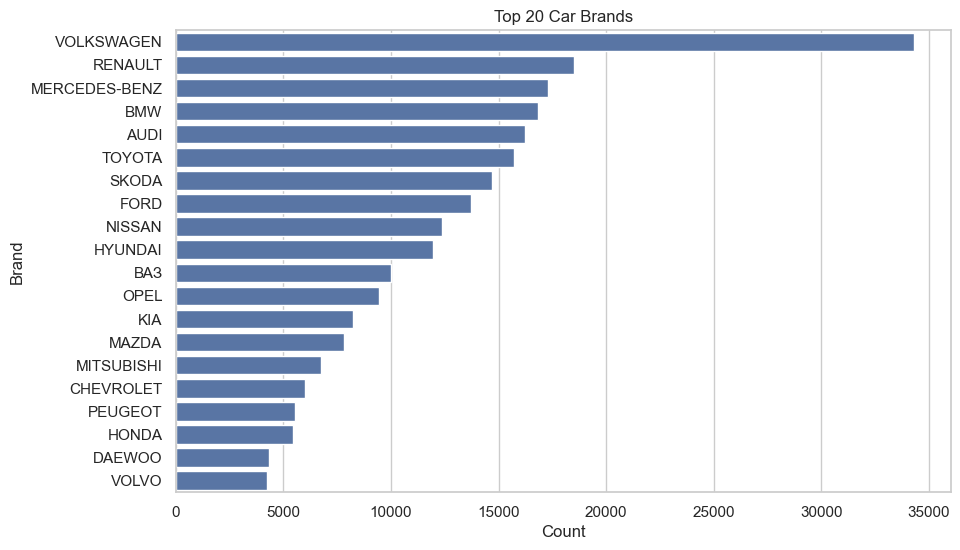

In [6]:
top_brands = df["BRAND"].value_counts().head(20)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 20 Car Brands")
plt.xlabel("Count")
plt.ylabel("Brand")

plt.show()

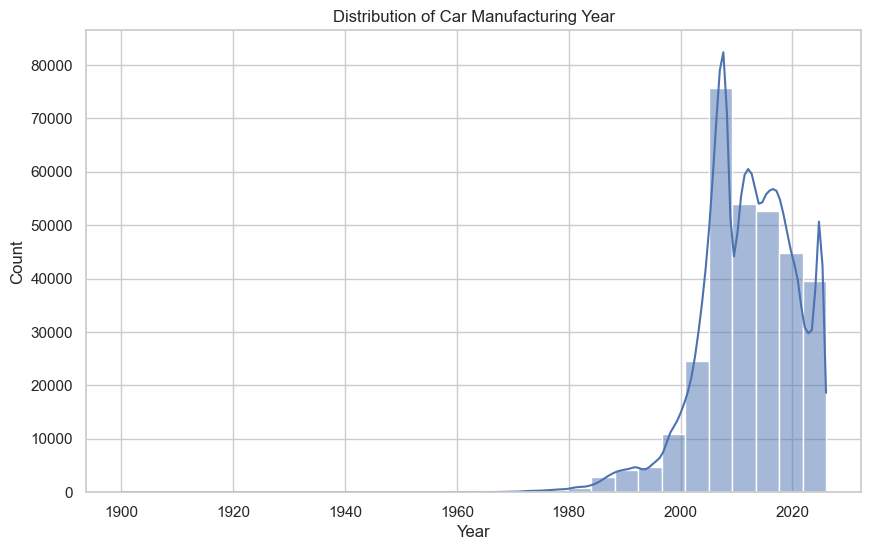

In [7]:
sns.histplot(
    df["MAKE_YEAR"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Car Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

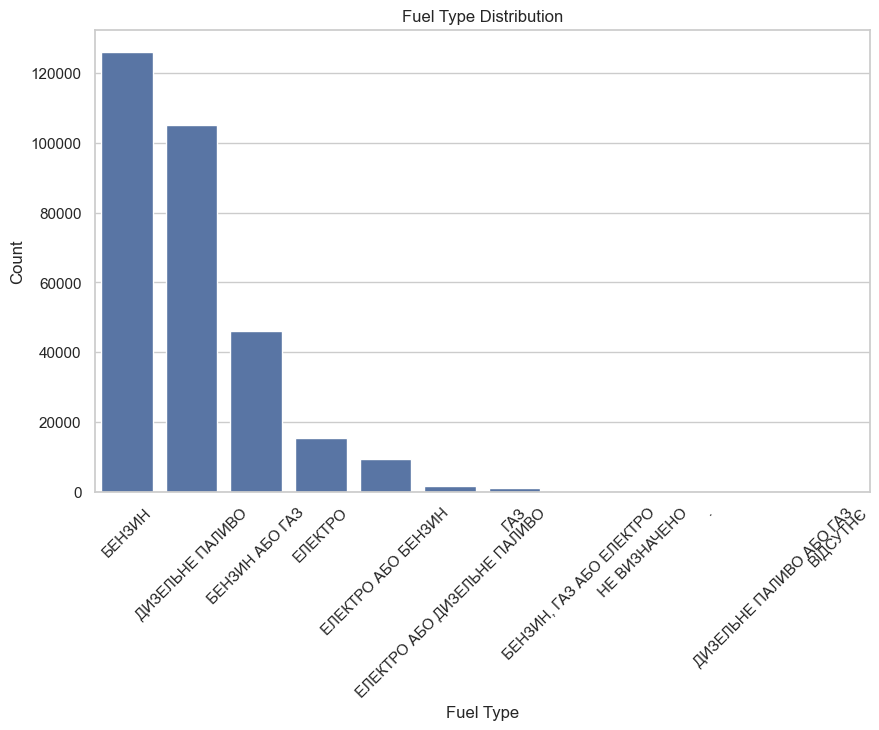

In [8]:
fuel_counts = df["FUEL"].value_counts()

sns.barplot(
    x=fuel_counts.index,
    y=fuel_counts.values
)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

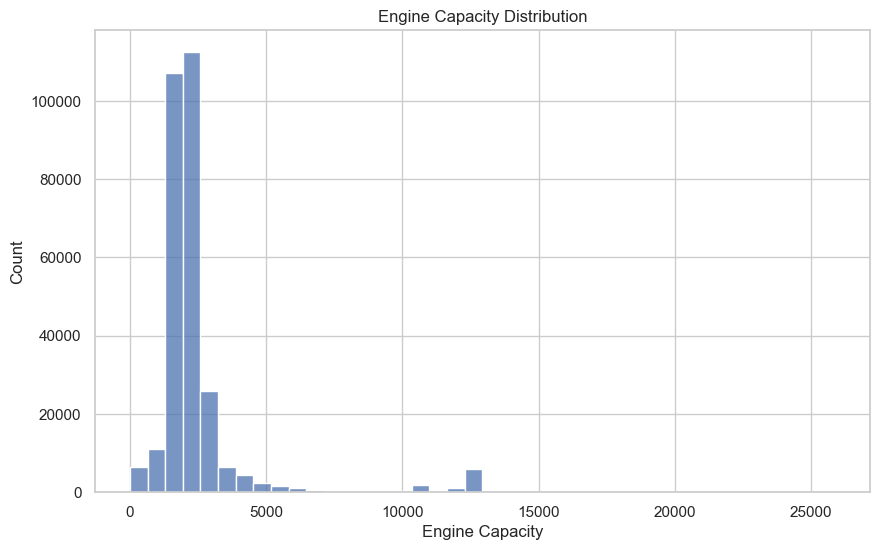

In [9]:
sns.histplot(
    df["CAPACITY"].dropna(),
    bins=40
)

plt.title("Engine Capacity Distribution")
plt.xlabel("Engine Capacity")
plt.ylabel("Count")

plt.show()

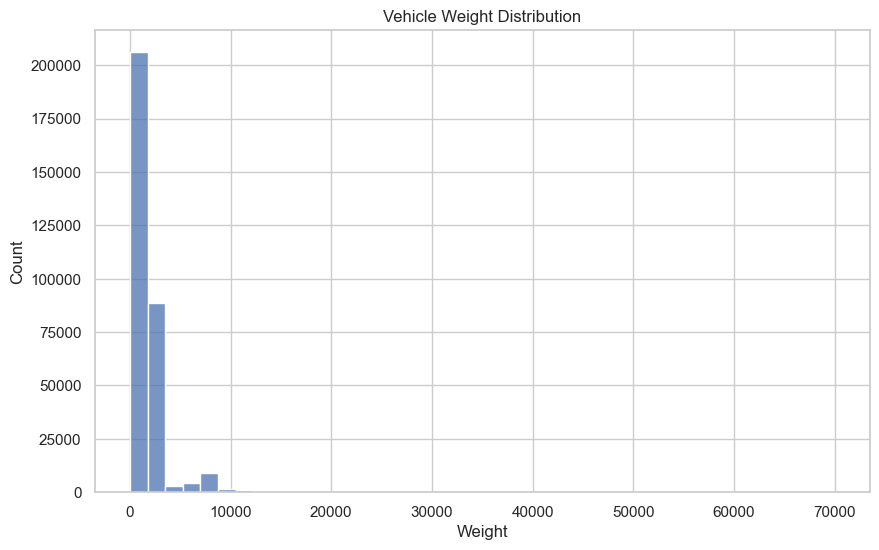

In [10]:
sns.histplot(
    df["OWN_WEIGHT"].dropna(),
    bins=40
)

plt.title("Vehicle Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Count")

plt.show()

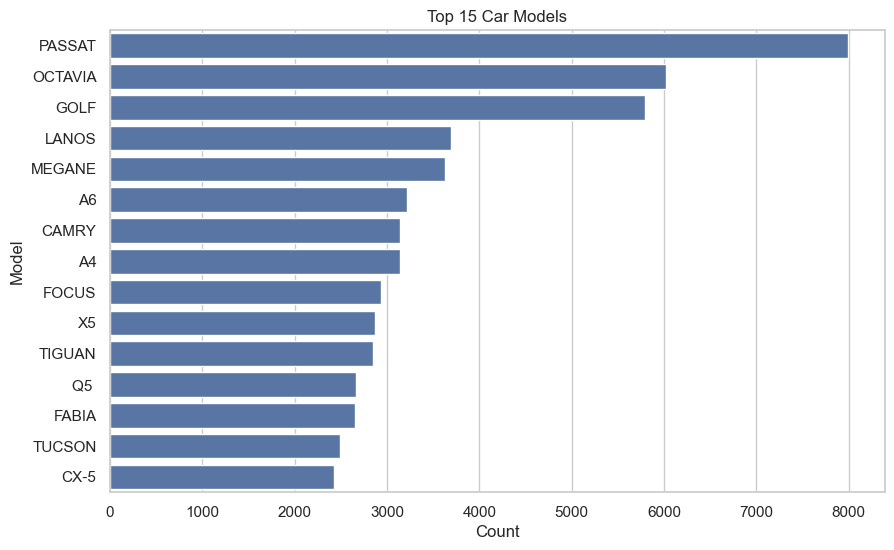

In [11]:
top_models = df["MODEL"].value_counts().head(15)

sns.barplot(
    x=top_models.values,
    y=top_models.index
)

plt.title("Top 15 Car Models")
plt.xlabel("Count")
plt.ylabel("Model")

plt.show()

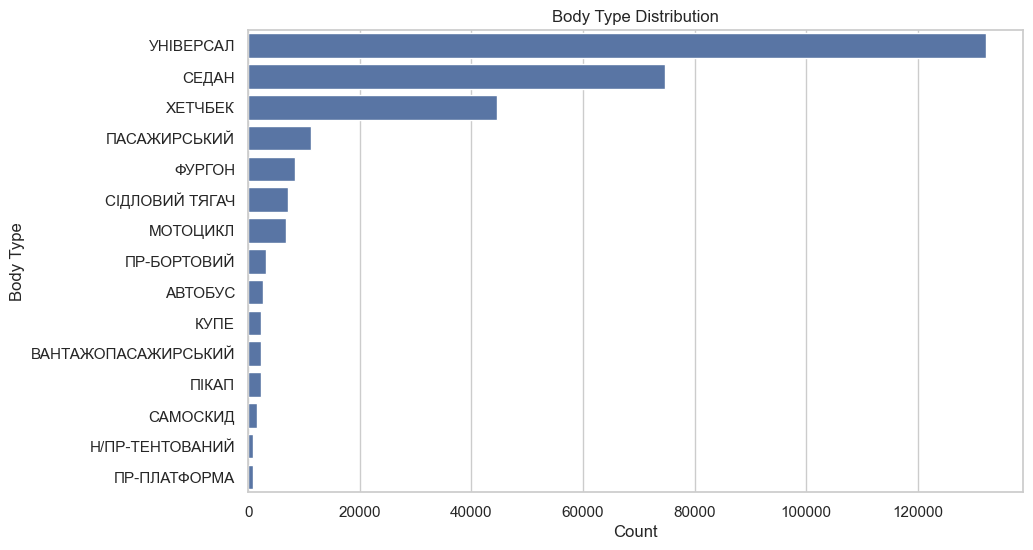

In [12]:
body_counts = df["BODY"].value_counts().head(15)

sns.barplot(
    x=body_counts.values,
    y=body_counts.index
)

plt.title("Body Type Distribution")
plt.xlabel("Count")
plt.ylabel("Body Type")

plt.show()

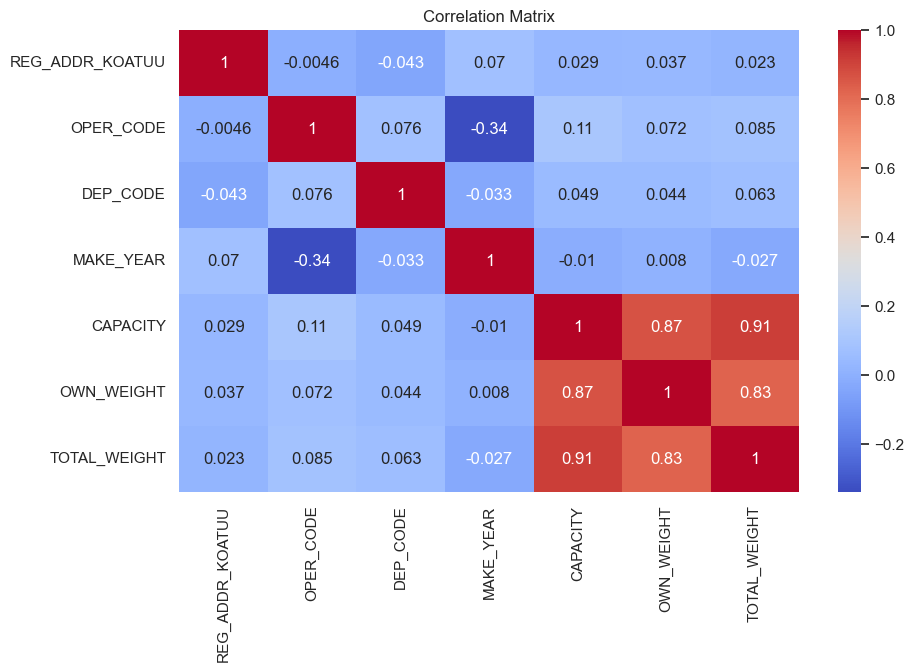

In [13]:
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

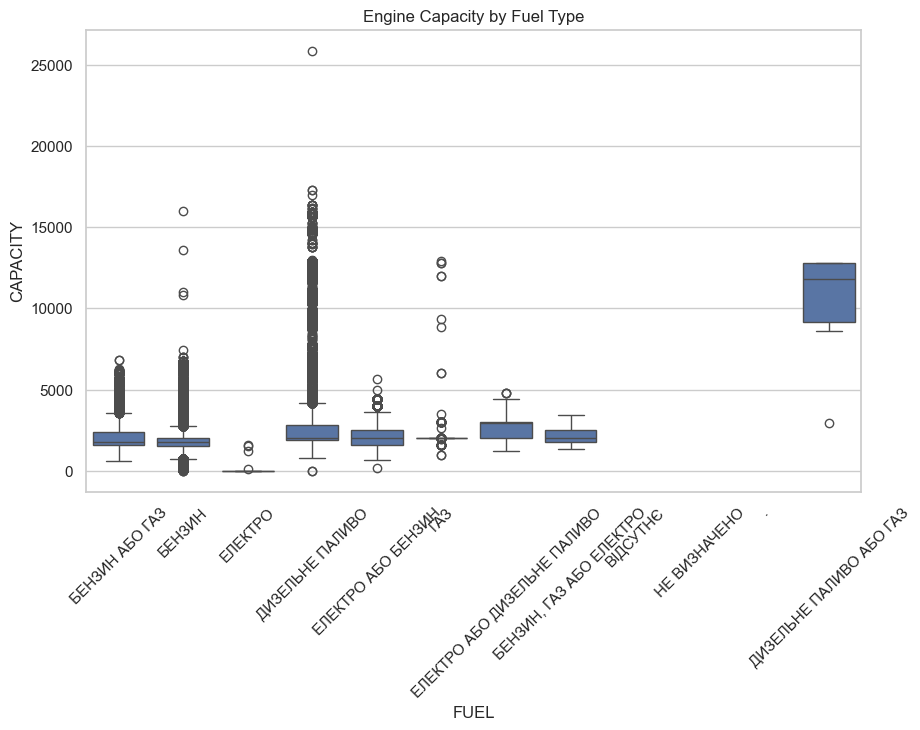

In [15]:
sns.boxplot(
    x="FUEL",
    y="CAPACITY",
    data=df
)

plt.xticks(rotation=45)

plt.title("Engine Capacity by Fuel Type")

plt.show()